# 05d — Matched latent simulator and spatial-GNN rollout comparison


In [2]:
%matplotlib inline

import os
import sys
from pathlib import Path

os.environ.setdefault("MPLBACKEND", "module://matplotlib_inline.backend_inline")
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "src" / "lss").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from matplotlib.colors import Normalize

from lss.latent.analysis import framewise_latent_descriptor_sweep
from lss.latent.capacity import experiment_config_fingerprint, final_05_2d_propagator_config
from lss.latent.experiment import run_latent_experiment, seed_everything
from lss.latent.simulation import pearson_r, r2_score
from lss.plotting import PAPER_COLORS, apply_editorial_style, style_axes
from lss.utils import resolve_device

apply_editorial_style()
DEVICE = resolve_device("auto")
DEVICE


'cuda'

## Shared 05b configuration


In [3]:
BASE_SEED = 20260710
FORCE_TRAIN = False

TRAIN_COUNT = 20
VAL_COUNT = 20
LATENT_DIM = 2
LATENT_TOKENS = 32
HIDDEN_SIZE = 96
AUTOENCODER_MODEL = "attention"

TRAIN_STEPS_PER_SIM = 100
MAX_EPOCHS = 80
PATIENCE = 8
LEARNING_RATE = 5e-5
WEIGHT_DECAY = 1e-5
FRAME_STRIDE = 4
MAX_ANALYSIS_FRAMES_PER_SIM = 100
ROLLOUT_STEPS_GRID = [10, 20, 50, 100, 150, 199]
ROLLOUT_EVAL_MAX_SIMS_PER_SPLIT = 30

OUTPUT_DIR = PROJECT_ROOT / "notebooks" / "results" / "05b_20net_latent_rollout"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CASES = {
    "depablo_low_temp": {
        "dataset_name": "depablo_low_temp",
        "label": "dePablo",
        "path": PROJECT_ROOT / "data" / "depablo-near-zero-temp.pt",
    },
    "reid": {
        "dataset_name": "reid",
        "label": "Reid",
        "path": PROJECT_ROOT / "data" / "reid_200_frames.pt",
    },
    "depablo_mixed_temp": {
        "dataset_name": "depablo_mixed_temp",
        "label": "dePablo mixed-T",
        "path": PROJECT_ROOT / "data" / "depablo-10k-mix-temp.pt",
    },
}

for key, spec in CASES.items():
    assert spec["path"].exists(), f"Missing dataset for {key}: {spec['path']}"

DATASET_STYLE = {
    "depablo_low_temp": {"color": PAPER_COLORS["blue"], "marker": "o", "short": "dePablo"},
    "reid": {"color": PAPER_COLORS["red"], "marker": "s", "short": "Reid"},
    "depablo_mixed_temp": {"color": PAPER_COLORS["green"], "marker": "^", "short": "dePablo mixed-T"},
}


In [4]:
def build_case_config(case_key: str, case_spec: dict, *, seed: int) -> tuple[dict, dict]:
    case_dir = OUTPUT_DIR / case_key
    case_dir.mkdir(parents=True, exist_ok=True)
    shared_dir = OUTPUT_DIR / 'capacity_sweep' / case_key
    shared_dir.mkdir(parents=True, exist_ok=True)
    ae_config = {
        "latent_dim": LATENT_DIM, "latent_tokens": LATENT_TOKENS, "hidden_size": HIDDEN_SIZE,
        "model": AUTOENCODER_MODEL, "edge_feature_dim": 12,
        "target_mode": "normalized_delta", "node_feature_mode": "normalized_delta",
        "max_train_frames_per_sim": TRAIN_STEPS_PER_SIM + 1, "max_epochs": MAX_EPOCHS,
        "patience": PATIENCE, "lr": LEARNING_RATE, "weight_decay": WEIGHT_DECAY,
    }
    propagator_config = {
        "max_train_transitions_per_sim": TRAIN_STEPS_PER_SIM, "max_epochs": MAX_EPOCHS,
        "patience": PATIENCE, "lr": LEARNING_RATE, "weight_decay": WEIGHT_DECAY,
        "use_static_context": True, "context_dim": 16, "step_stride": 1,
        "initial_velocity": "zero", "objective": "one_step", "model": "delta_mlp",
        "loss": "delta", "standardize_latent": False,
        "rollout_eval_every_epoch": True, "rollout_eval_horizon": 100, "rollout_eval_max_sims": None,
    }
    experiment_config = {
        "ae_config": ae_config, "propagator_config": propagator_config,
        "dataset_name": case_spec["dataset_name"],
        "split_seed": seed,
        "split_stratify_temperature": False,
        "min_train_p_ratio": None,
        "device": str(DEVICE),
        "pos_dim": 2,
        "batch_graphs": 4,
        "frame_skip": 1,
        "train_frame_start_order": 0,
        "early_stop_min_delta": 1e-5,
        "rollout_steps_grid": ROLLOUT_STEPS_GRID,
        "rollout_eval_max_sims_per_split": ROLLOUT_EVAL_MAX_SIMS_PER_SPLIT,
        "should_rollout": True,
        "should_train_propagator": True,
        "force_train": bool(FORCE_TRAIN),
        "cache_path": None,
        "model_seed": seed,
        "repeat_idx": 1,
    }
    cache_identity = {**experiment_config, 'source_path': str(case_spec['path']), 'train_count': TRAIN_COUNT, 'val_count': VAL_COUNT}
    cache_tag = experiment_config_fingerprint(cache_identity)
    base_cache_path = shared_dir / f'rollout_{AUTOENCODER_MODEL}_cv{LATENT_DIM}_train{TRAIN_COUNT}_{cache_tag}.pt'
    final_propagator = None
    if final_propagator is None:
        experiment_config['cache_path'] = str(base_cache_path)
    else:
        cache_name = final_propagator.pop('cache_name')
        ae_cache_name = final_propagator.pop('ae_cache_name', None)
        final_propagator.pop('seed_offset')
        experiment_config.update(final_propagator)
        experiment_config['pretrained_ae_cache_path'] = str(base_cache_path if ae_cache_name is None else OUTPUT_DIR/'propagator_optimization'/case_key/ae_cache_name)
        experiment_config['cache_path'] = str(OUTPUT_DIR/'propagator_optimization'/case_key/cache_name)
    source_spec = {
        "dataset_name": case_spec["dataset_name"],
        "source_name": case_spec["label"],
        "label": f"{case_spec['label']} CV{LATENT_DIM}, train={TRAIN_COUNT}",
        "path": str(case_spec["path"]),
        "dataset_mixture": [
            {
                "name": case_spec["dataset_name"],
                "label": case_spec["label"],
                "path": str(case_spec["path"]),
                "train_count": TRAIN_COUNT,
                "val_count": VAL_COUNT,
            }
        ],
    }
    return experiment_config, source_spec


def run_or_load_case(case_key: str, case_spec: dict) -> dict:
    seed = BASE_SEED + 101 * (list(CASES).index(case_key) + 1)
    experiment_config, source_spec = build_case_config(case_key, case_spec, seed=seed)
    seed_everything(seed)
    result = run_latent_experiment(source_spec, experiment_config, device=DEVICE)
    result["case_key"] = case_key
    result["case_label"] = case_spec["label"]
    result["case_cfg"] = experiment_config
    return result


## Load cached latent simulators


In [5]:
results = {key: run_or_load_case(key, spec) for key, spec in CASES.items()}

split_tables = []
for key, result in results.items():
    table = result["split_info"].copy()
    table.insert(0, "case", key)
    split_tables.append(table)
split_info = pd.concat(split_tables, ignore_index=True)
split_info.to_csv(OUTPUT_DIR / "split_info.csv", index=False)
display(split_info)


loading cached latent experiment: /home/alexz/Documents/course_project/notebooks/results/05b_20net_latent_rollout/propagator_optimization/depablo_low_temp/final_2d_single_stage_h64_one_step.pt
loading cached latent experiment: /home/alexz/Documents/course_project/notebooks/results/05b_20net_latent_rollout/propagator_optimization/reid/final_2d_attention_h96_train30_one_step.pt
loading cached latent experiment: /home/alexz/Documents/course_project/notebooks/results/05b_20net_latent_rollout/propagator_optimization/depablo_mixed_temp/../../depablo_mixed_temp/latent_rollout_attention_cv2_train20_frames100_epochs80_pat8_dyn_epochs80_dynpat8_seed20261013.pt


,case,source,path,total,train,reserved_train_pool,val,test
0,depablo_low_temp,depablo_low_temp,/home/alexz/Documents/course_project/data/depa...,200,20,20,20,160
1,reid,reid,/home/alexz/Documents/course_project/data/reid...,102,30,30,20,52
2,depablo_mixed_temp,depablo_mixed_temp,/home/alexz/Documents/course_project/data/depa...,300,20,20,20,260


## Matched spatial-GNN rollout comparison


loading matched GNN: /home/alexz/Documents/course_project/notebooks/results/05b_20net_latent_rollout/matched_gnn/reid_spatial_gnn_train20_seed20260912/final_checkpoint.pt
loading matched GNN: /home/alexz/Documents/course_project/notebooks/results/05b_20net_latent_rollout/matched_gnn/depablo_mixed_temp_spatial_gnn_train20_seed20261013/final_checkpoint.pt


,case,dataset_label,model,rollout_steps,used,p_ratio_r2,p_ratio_pearson,position_mse
0,reid,Reid,latent simulator,10,30,0.75677,0.91998,1.000000e-05
1,reid,Reid,latent simulator,20,30,0.79885,0.91396,1.000000e-05
2,reid,Reid,latent simulator,50,30,0.80987,0.90987,7.000000e-05
3,reid,Reid,latent simulator,100,30,0.76292,0.89930,2.700000e-04
4,reid,Reid,latent simulator,150,30,0.56537,0.90491,9.900000e-04
5,reid,Reid,latent simulator,199,30,0.64279,0.90769,2.470000e-03
6,depablo_mixed_temp,dePablo mixed-T,latent simulator,10,30,0.07701,0.62873,1.400000e-03
7,depablo_mixed_temp,dePablo mixed-T,latent simulator,20,30,-0.52920,0.39678,1.530000e-03
8,depablo_mixed_temp,dePablo mixed-T,latent simulator,50,30,0.44681,0.74370,1.570000e-03
9,depablo_mixed_temp,dePablo mixed-T,latent simulator,100,30,0.71990,0.90379,1.950000e-03


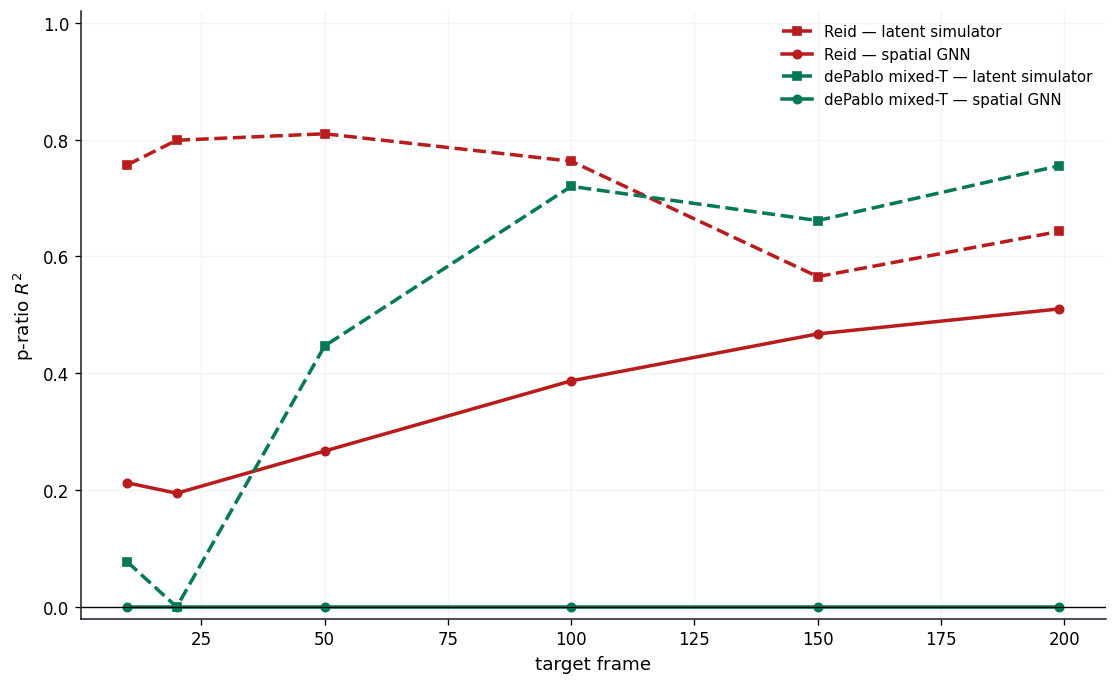

In [8]:
from lss.matched_gnn import run_matched_spatial_gnns

GNN_CASE_KEYS = ['reid', 'depablo_mixed_temp']
GNN_FORCE_TRAIN = False
GNN_EPOCHS = 40

matched_comparison = run_matched_spatial_gnns(
    cases=CASES, latent_results=results, case_keys=GNN_CASE_KEYS,
    all_case_keys=list(CASES), base_seed=BASE_SEED,
    train_count=TRAIN_COUNT, val_count=VAL_COUNT,
    train_frames=TRAIN_STEPS_PER_SIM, rollout_steps=ROLLOUT_STEPS_GRID,
    eval_count=ROLLOUT_EVAL_MAX_SIMS_PER_SPLIT,
    device=DEVICE, output_dir=OUTPUT_DIR,
    epochs=GNN_EPOCHS, force_train=GNN_FORCE_TRAIN,
)
matched_comparison.to_csv(OUTPUT_DIR/'matched_latent_vs_spatial_gnn.csv', index=False)
display(matched_comparison.round(5))

fig, ax = plt.subplots(figsize=(9.2, 5.6), constrained_layout=True)
dataset_colors = {'reid': PAPER_COLORS['red'], 'depablo_mixed_temp': PAPER_COLORS['green']}
model_styles = {'latent simulator': ('--', 's'), 'spatial GNN': ('-', 'o')}
for key in GNN_CASE_KEYS:
    subset = matched_comparison[matched_comparison.case.eq(key)]
    for model_name, group in subset.groupby('model', sort=False):
        line_style, marker = model_styles[model_name]
        group = group.sort_values('rollout_steps')
        display_r2 = group.p_ratio_r2.clip(lower=0)
        ax.plot(group.rollout_steps, display_r2, marker=marker, color=dataset_colors[key],
                ls=line_style, lw=2.1, ms=5, label=f"{CASES[key]['label']} — {model_name}")
ax.axhline(0, color='black', lw=.8)
# ax.set_title('Latent simulator versus spatial GNN')
style_axes(ax, xlabel='target frame', ylabel='p-ratio $R^2$', legend=True)
ax.set_ylim(-0.02, 1.02)
fig.savefig(OUTPUT_DIR/'matched_latent_vs_spatial_gnn_combined.png', dpi=300, bbox_inches='tight')
fig.savefig(OUTPUT_DIR/'matched_latent_vs_spatial_gnn_combined.pdf', bbox_inches='tight')
plt.show()
